# Student vs Digital Distraction Model
### Import Library and Models

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

#import Categorical Naive Bayes Model
from sklearn.naive_bayes import CategoricalNB

#import Logistic Regression model 
from sklearn.linear_model import LogisticRegression

#import Decision Tree model
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

### Import Dataset

In [2]:
data = pd.read_csv("student_digital_life.csv",  sep=",")
#NOTICE: To rerun the program again, you HAVE TO import the original dataset to the project folder. Because all the function that is used to update the column will mess up with the original dataset

### Display Dataset information 

In [3]:
display(data.head())
display(data.info())
display(data.describe(include="all"))

,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score
0,1,21,Female,3.01,0.26,1.77,0.26,1.71,5.32,0.70,64.87,74.11,2,Good,Masters,Average,6.32,82.70
1,2,23,Female,5.84,8.02,3.30,0.96,0.00,5.99,1.99,85.38,80.68,3,Average,Masters,Poor,2.52,85.65
2,3,20,Female,7.80,10.13,0.00,2.23,2.54,6.36,1.82,76.15,79.69,2,Good,HighSchool,Poor,3.98,88.14
3,4,20,Female,0.00,1.15,1.32,4.19,0.27,7.86,0.18,84.41,79.07,0,Average,HighSchool,Average,4.77,54.81
4,5,24,Male,7.23,1.39,2.21,4.67,2.75,7.88,0.28,81.13,65.40,4,Good,HighSchool,Average,8.77,84.34


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     15000 non-null  int64  
 1   age                            15000 non-null  int64  
 2   gender                         15000 non-null  object 
 3   study_hours_per_day            15000 non-null  float64
 4   smartphone_usage_hours         15000 non-null  float64
 5   social_media_hours             15000 non-null  float64
 6   gaming_hours                   15000 non-null  float64
 7   streaming_hours                15000 non-null  float64
 8   sleep_hours                    15000 non-null  float64
 9   exercise_hours                 15000 non-null  float64
 10  class_attendance_percent       15000 non-null  float64
 11  assignment_completion_percent  15000 non-null  float64
 12  caffeine_intake_cups           15000 non-null 

None

,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score
count,15000.000000,15000.000000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000,15000,15000,15000.000000,15000.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,4,3,NaN,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Average,HighSchool,Average,NaN,NaN
freq,NaN,NaN,7747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6792,6057,7564,NaN,NaN
mean,7500.500000,21.024400,NaN,4.511505,5.503475,3.516837,2.241304,1.829245,6.997377,1.234827,84.631745,79.445435,1.504933,NaN,NaN,NaN,5.988216,80.344360
std,4330.271354,2.594299,NaN,1.981043,2.437488,1.767000,1.468125,1.132042,1.456868,0.827273,9.452752,13.918023,1.227060,NaN,NaN,NaN,1.949031,18.434455
min,1.000000,17.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,3.500000,0.000000,44.960000,30.000000,0.000000,NaN,NaN,NaN,1.000000,2.630000
25%,3750.750000,19.000000,NaN,3.167500,3.830000,2.280000,1.110000,0.990000,5.970000,0.600000,78.180000,70.007500,1.000000,NaN,NaN,NaN,4.650000,68.730000
50%,7500.500000,21.000000,NaN,4.510000,5.480000,3.490000,2.175000,1.780000,6.990000,1.190000,84.895000,80.220000,1.000000,NaN,NaN,NaN,6.000000,83.745000
75%,11250.250000,23.000000,NaN,5.840000,7.150000,4.710000,3.260000,2.600000,8.030000,1.800000,91.650000,90.275000,2.000000,NaN,NaN,NaN,7.340000,97.810000


### WIP: Cleaning data and ready for training 

In [4]:
#drop unnecessary data
data.drop(columns=['parent_education_level'], inplace = True)
data.drop(columns=['internet_quality'], inplace = True)
data.drop(columns=['motivation_level'], inplace = True)
data.drop(columns=['exercise_hours'], inplace = True)
data.drop(columns=['caffeine_intake_cups'], inplace = True)

#data.dropna(axis=1, how="all", inplace=True)
#df = df.drop(columns=['column_name'])

display(data.head())
display(data.info())
display(data.describe(include="all"))

,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,class_attendance_percent,assignment_completion_percent,mental_health_status,final_exam_score
0,1,21,Female,3.01,0.26,1.77,0.26,1.71,5.32,64.87,74.11,Good,82.70
1,2,23,Female,5.84,8.02,3.30,0.96,0.00,5.99,85.38,80.68,Average,85.65
2,3,20,Female,7.80,10.13,0.00,2.23,2.54,6.36,76.15,79.69,Good,88.14
3,4,20,Female,0.00,1.15,1.32,4.19,0.27,7.86,84.41,79.07,Average,54.81
4,5,24,Male,7.23,1.39,2.21,4.67,2.75,7.88,81.13,65.40,Good,84.34


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     15000 non-null  int64  
 1   age                            15000 non-null  int64  
 2   gender                         15000 non-null  object 
 3   study_hours_per_day            15000 non-null  float64
 4   smartphone_usage_hours         15000 non-null  float64
 5   social_media_hours             15000 non-null  float64
 6   gaming_hours                   15000 non-null  float64
 7   streaming_hours                15000 non-null  float64
 8   sleep_hours                    15000 non-null  float64
 9   class_attendance_percent       15000 non-null  float64
 10  assignment_completion_percent  15000 non-null  float64
 11  mental_health_status           15000 non-null  object 
 12  final_exam_score               15000 non-null 

None

,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,class_attendance_percent,assignment_completion_percent,mental_health_status,final_exam_score
count,15000.000000,15000.000000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000,15000.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Average,NaN
freq,NaN,NaN,7747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6792,NaN
mean,7500.500000,21.024400,NaN,4.511505,5.503475,3.516837,2.241304,1.829245,6.997377,84.631745,79.445435,NaN,80.344360
std,4330.271354,2.594299,NaN,1.981043,2.437488,1.767000,1.468125,1.132042,1.456868,9.452752,13.918023,NaN,18.434455
min,1.000000,17.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,3.500000,44.960000,30.000000,NaN,2.630000
25%,3750.750000,19.000000,NaN,3.167500,3.830000,2.280000,1.110000,0.990000,5.970000,78.180000,70.007500,NaN,68.730000
50%,7500.500000,21.000000,NaN,4.510000,5.480000,3.490000,2.175000,1.780000,6.990000,84.895000,80.220000,NaN,83.745000
75%,11250.250000,23.000000,NaN,5.840000,7.150000,4.710000,3.260000,2.600000,8.030000,91.650000,90.275000,NaN,97.810000


### Combining time spent not study into one variable 

In [5]:
df = pd.DataFrame(data)
cols = ["social_media_hours", "gaming_hours", "streaming_hours", "smartphone_usage_hours"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")
df["digital_distraction_time"] = df[cols].sum(axis=1)
print(df[["social_media_hours", "gaming_hours", "streaming_hours", "digital_distraction_time"]].head())

df.to_csv("student_digital_life.csv", index=False)
data = pd.read_csv("student_digital_life.csv")

display(data.head())


   social_media_hours  gaming_hours  streaming_hours  digital_distraction_time
0                1.77          0.26             1.71                      4.00
1                3.30          0.96             0.00                     12.28
2                0.00          2.23             2.54                     14.90
3                1.32          4.19             0.27                      6.93
4                2.21          4.67             2.75                     11.02


,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,class_attendance_percent,assignment_completion_percent,mental_health_status,final_exam_score,digital_distraction_time
0,1,21,Female,3.01,0.26,1.77,0.26,1.71,5.32,64.87,74.11,Good,82.70,4.00
1,2,23,Female,5.84,8.02,3.30,0.96,0.00,5.99,85.38,80.68,Average,85.65,12.28
2,3,20,Female,7.80,10.13,0.00,2.23,2.54,6.36,76.15,79.69,Good,88.14,14.90
3,4,20,Female,0.00,1.15,1.32,4.19,0.27,7.86,84.41,79.07,Average,54.81,6.93
4,5,24,Male,7.23,1.39,2.21,4.67,2.75,7.88,81.13,65.40,Good,84.34,11.02


Pass: 73.2%, Fail: 26.8%
Features: ['age', 'gender', 'study_hours_per_day', 'sleep_hours', 'class_attendance_percent', 'assignment_completion_percent', 'mental_health_status', 'digital_distraction_time']
Train: 12000, Test: 3000

LOGISTIC REGRESSION
Accuracy:  0.8407
Precision: 0.8668
Recall:    0.9244
F1-Score:  0.8947
5-fold CV F1: 0.8942 (+/- 0.0055)

Confusion Matrix:
[[ 491  312]
 [ 166 2031]]

Classification Report:
              precision    recall  f1-score   support

        Fail     0.7473    0.6115    0.6726       803
        Pass     0.8668    0.9244    0.8947      2197

    accuracy                         0.8407      3000
   macro avg     0.8071    0.7679    0.7837      3000
weighted avg     0.8349    0.8407    0.8353      3000


Coefficients:
                         feature  coefficient
2            study_hours_per_day     2.062553
6           mental_health_status     0.635051
5  assignment_completion_percent     0.585524
7       digital_distraction_time    -0.457749
4 

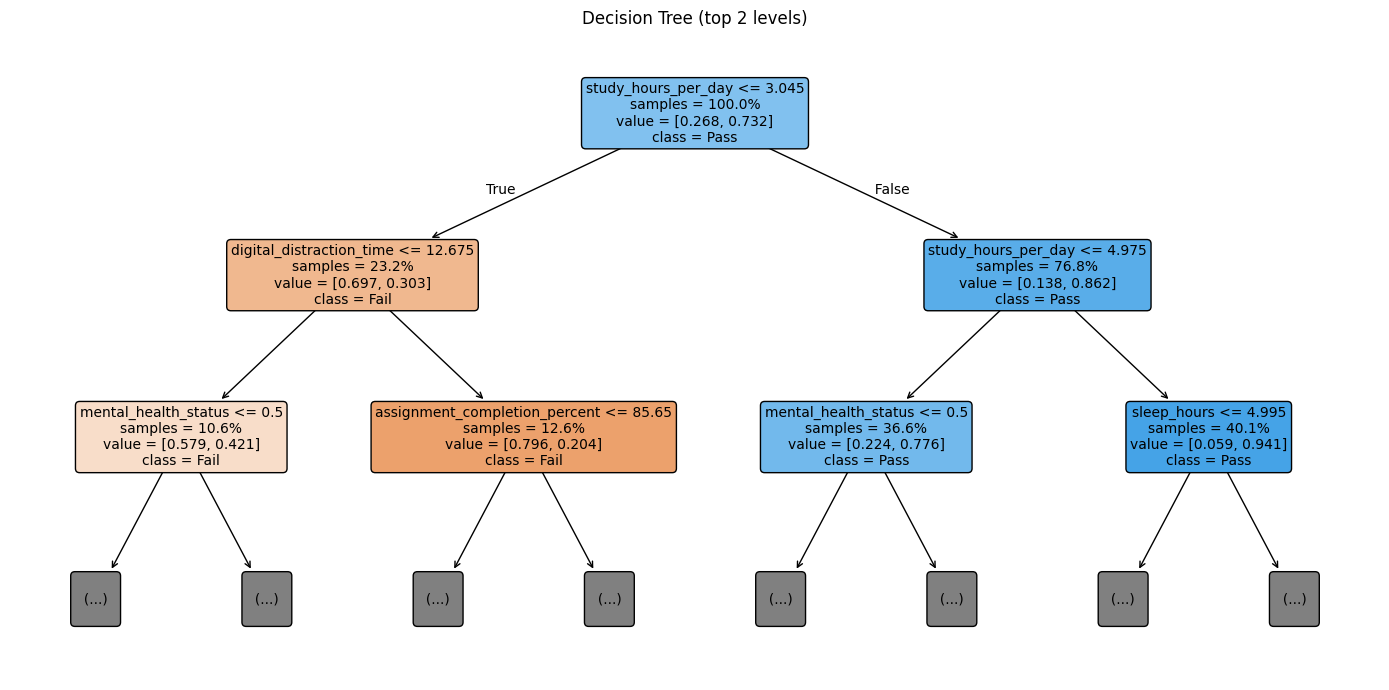

In [10]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# ============================================================
# Prepare features and target
# ============================================================
data["performance"] = (data["final_exam_score"] >= 70).astype(int)

df_model = data.drop(columns=[
    "student_id", "final_exam_score",
    "smartphone_usage_hours", "social_media_hours",
    "gaming_hours", "streaming_hours"
])

df_model["gender"] = df_model["gender"].map({"Female": 0, "Male": 1})
df_model["mental_health_status"] = df_model["mental_health_status"].map({"Poor": 0, "Average": 1, "Good": 2})

X = df_model.drop(columns=["performance"])
y = df_model["performance"]

print(f"Pass: {(y==1).mean():.1%}, Fail: {(y==0).mean():.1%}")
print(f"Features: {list(X.columns)}")

# ============================================================
# Train/test split (80/20, stratified)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# ============================================================
# Logistic Regression
# ============================================================
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
lr_pred = logreg.predict(X_test_scaled)

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)

print("\nLOGISTIC REGRESSION")
print(f"Accuracy:  {lr_acc:.4f}")
print(f"Precision: {lr_prec:.4f}")
print(f"Recall:    {lr_rec:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv = cross_val_score(logreg, X_train_scaled, y_train, cv=cv, scoring="f1")
print(f"5-fold CV F1: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=["Fail","Pass"], digits=4))

lr_coefs = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logreg.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)
print("\nCoefficients:")
print(lr_coefs)

# ============================================================
# Decision Tree
# ============================================================
dtree = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=42)
dtree.fit(X_train, y_train)
dt_pred = dtree.predict(X_test)

dt_acc  = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred)
dt_rec  = recall_score(y_test, dt_pred)
dt_f1   = f1_score(y_test, dt_pred)

print("\nDECISION TREE")
print(f"Accuracy:  {dt_acc:.4f}")
print(f"Precision: {dt_prec:.4f}")
print(f"Recall:    {dt_rec:.4f}")
print(f"F1-Score:  {dt_f1:.4f}")

dt_cv = cross_val_score(dtree, X_train, y_train, cv=cv, scoring="f1")
print(f"5-fold CV F1: {dt_cv.mean():.4f} (+/- {dt_cv.std():.4f})")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=["Fail","Pass"], digits=4))

dt_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": dtree.feature_importances_
}).sort_values("importance", ascending=False)
print("\nFeature Importances:")
print(dt_imp)

# Visualize tree (top 2 levels)
fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(dtree, feature_names=X.columns, class_names=["Fail","Pass"],
          filled=True, max_depth=2, fontsize=10, rounded=True,
          impurity=False, proportion=True, ax=ax)
plt.title("Decision Tree (top 2 levels)")
plt.tight_layout()
plt.show()